In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import scipy.stats as stats

In [2]:
data = pd.read_csv('../M1_final.csv')
# data = data.reset_index()
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28820 entries, 0 to 28819
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   MONTH              28820 non-null  int64  
 1   DAY_OF_MONTH       28820 non-null  int64  
 2   DAY_OF_WEEK        28820 non-null  int64  
 3   OP_UNIQUE_CARRIER  28820 non-null  object 
 4   TAIL_NUM           28820 non-null  object 
 5   DEST               28820 non-null  object 
 6   DEP_DELAY          28820 non-null  int64  
 7   CRS_ELAPSED_TIME   28820 non-null  int64  
 8   DISTANCE           28820 non-null  int64  
 9   CRS_DEP_M          28820 non-null  int64  
 10  DEP_TIME_M         28820 non-null  int64  
 11  CRS_ARR_M          28820 non-null  int64  
 12  Temperature        28820 non-null  int64  
 13  Dew Point          28820 non-null  object 
 14  Humidity           28820 non-null  int64  
 15  Wind               28818 non-null  object 
 16  Wind Speed         288

In [3]:
data.drop(columns=['TAIL_NUM', 'DEP_TIME_M', 'TAXI_OUT'], inplace=True)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28820 entries, 0 to 28819
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   MONTH              28820 non-null  int64  
 1   DAY_OF_MONTH       28820 non-null  int64  
 2   DAY_OF_WEEK        28820 non-null  int64  
 3   OP_UNIQUE_CARRIER  28820 non-null  object 
 4   DEST               28820 non-null  object 
 5   DEP_DELAY          28820 non-null  int64  
 6   CRS_ELAPSED_TIME   28820 non-null  int64  
 7   DISTANCE           28820 non-null  int64  
 8   CRS_DEP_M          28820 non-null  int64  
 9   CRS_ARR_M          28820 non-null  int64  
 10  Temperature        28820 non-null  int64  
 11  Dew Point          28820 non-null  object 
 12  Humidity           28820 non-null  int64  
 13  Wind               28818 non-null  object 
 14  Wind Speed         28820 non-null  int64  
 15  Wind Gust          28820 non-null  int64  
 16  Pressure           288

In [4]:
data = data.reset_index(drop=True)
data

,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,OP_UNIQUE_CARRIER,DEST,DEP_DELAY,CRS_ELAPSED_TIME,DISTANCE,CRS_DEP_M,CRS_ARR_M,Temperature,Dew Point,Humidity,Wind,Wind Speed,Wind Gust,Pressure,Condition,sch_dep,sch_arr
0,11,1,5,B6,CHS,-1,124,636,324,448,48,34,58,W,25,38,29.86,Fair / Windy,9,17
1,11,1,5,B6,LAX,-7,371,2475,340,531,48,34,58,W,25,38,29.86,Fair / Windy,9,17
2,11,1,5,B6,FLL,40,181,1069,301,482,48,34,58,W,25,38,29.86,Fair / Windy,9,17
3,11,1,5,B6,MCO,-2,168,944,345,513,48,34,58,W,25,38,29.86,Fair / Windy,9,17
4,11,1,5,DL,ATL,-4,139,760,360,499,46,32,58,W,24,35,29.91,Fair / Windy,9,17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28815,1,31,5,B6,ORH,2,57,150,1370,1427,39,38,96,N,6,0,30.18,Cloudy,20,32
28816,1,31,5,AA,BOS,2,75,187,1390,25,39,38,96,N,6,0,30.18,Cloudy,19,23
28817,1,31,5,AS,SEA,283,392,2422,1125,1337,39,38,96,N,6,0,30.18,Cloudy,19,23
28818,1,31,5,B6,SJU,5,224,1598,1417,261,39,38,96,N,6,0,30.18,Cloudy,19,23


### Create target variable is_Delayed

In [5]:
data['is_delayed'] = np.where(
    data['DEP_DELAY'] >= 15,
    1,
    0
)

In [6]:
data.sample(10)

,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,OP_UNIQUE_CARRIER,DEST,DEP_DELAY,CRS_ELAPSED_TIME,DISTANCE,CRS_DEP_M,CRS_ARR_M,...,Dew Point,Humidity,Wind,Wind Speed,Wind Gust,Pressure,Condition,sch_dep,sch_arr,is_delayed
4153,11,13,3,DL,SJU,3,234,1598,1139,1433,...,6,36,N,8,0,30.42,Partly Cloudy,39,29,0
27922,1,29,3,DL,FLL,-4,192,1069,685,877,...,19,48,N,16,0,30.09,Fair,26,16,0
14779,12,18,3,DL,AUS,41,277,1521,545,762,...,26,67,WSW,12,0,29.87,Fair,34,17,1
13525,12,14,6,DL,LAX,-7,385,2475,585,790,...,54,10,SSE,5,0,29.44,Cloudy,35,16,0
6868,11,21,4,DL,SEA,9,391,2422,1114,1325,...,40,74,SSW,10,0,30.09,Mostly Cloudy,41,33,0
15806,12,21,6,AA,LAX,0,389,2475,1230,1439,...,29,85,SSW,3,0,30.48,Mostly Cloudy,35,42,0
24596,1,19,7,DL,STT,0,233,1623,492,785,...,31,62,WNW,13,23,29.70,Partly Cloudy,45,19,0
19944,1,4,6,YX,ORD,-5,183,740,485,608,...,46,10,ESE,10,0,29.68,Light Drizzle,50,18,0
23689,1,15,3,DL,SFO,0,427,2586,1165,1412,...,35,68,WSW,7,0,30.13,Partly Cloudy,38,34,0
18091,12,29,7,B6,FLL,-8,186,1069,373,559,...,31,92,CALM,0,0,30.23,Partly Cloudy,19,25,0


In [7]:
data.shape

(28820, 21)

### Drop null rows

In [8]:
data.isnull().sum()

MONTH                0
DAY_OF_MONTH         0
DAY_OF_WEEK          0
OP_UNIQUE_CARRIER    0
DEST                 0
DEP_DELAY            0
CRS_ELAPSED_TIME     0
DISTANCE             0
CRS_DEP_M            0
CRS_ARR_M            0
Temperature          0
Dew Point            0
Humidity             0
Wind                 2
Wind Speed           0
Wind Gust            0
Pressure             0
Condition            0
sch_dep              0
sch_arr              0
is_delayed           0
dtype: int64

In [9]:
data.dropna(inplace=True)
data.isnull().sum()

MONTH                0
DAY_OF_MONTH         0
DAY_OF_WEEK          0
OP_UNIQUE_CARRIER    0
DEST                 0
DEP_DELAY            0
CRS_ELAPSED_TIME     0
DISTANCE             0
CRS_DEP_M            0
CRS_ARR_M            0
Temperature          0
Dew Point            0
Humidity             0
Wind                 0
Wind Speed           0
Wind Gust            0
Pressure             0
Condition            0
sch_dep              0
sch_arr              0
is_delayed           0
dtype: int64

In [10]:
data.shape

(28818, 21)

In [11]:
# Reset index after dropping to avoid discrepencies
data = data.reset_index(drop=True)
data

,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,OP_UNIQUE_CARRIER,DEST,DEP_DELAY,CRS_ELAPSED_TIME,DISTANCE,CRS_DEP_M,CRS_ARR_M,...,Dew Point,Humidity,Wind,Wind Speed,Wind Gust,Pressure,Condition,sch_dep,sch_arr,is_delayed
0,11,1,5,B6,CHS,-1,124,636,324,448,...,34,58,W,25,38,29.86,Fair / Windy,9,17,0
1,11,1,5,B6,LAX,-7,371,2475,340,531,...,34,58,W,25,38,29.86,Fair / Windy,9,17,0
2,11,1,5,B6,FLL,40,181,1069,301,482,...,34,58,W,25,38,29.86,Fair / Windy,9,17,1
3,11,1,5,B6,MCO,-2,168,944,345,513,...,34,58,W,25,38,29.86,Fair / Windy,9,17,0
4,11,1,5,DL,ATL,-4,139,760,360,499,...,32,58,W,24,35,29.91,Fair / Windy,9,17,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28813,1,31,5,B6,ORH,2,57,150,1370,1427,...,38,96,N,6,0,30.18,Cloudy,20,32,0
28814,1,31,5,AA,BOS,2,75,187,1390,25,...,38,96,N,6,0,30.18,Cloudy,19,23,0
28815,1,31,5,AS,SEA,283,392,2422,1125,1337,...,38,96,N,6,0,30.18,Cloudy,19,23,1
28816,1,31,5,B6,SJU,5,224,1598,1417,261,...,38,96,N,6,0,30.18,Cloudy,19,23,0


### Wind column

In [12]:
data['Wind'].unique()

array(['W', 'WNW', 'NW', 'NNW', 'S', 'ENE', 'NE', 'NNE', 'E', 'SE',
       'CALM', 'SW', 'VAR', 'SSE', 'SSW', 'WSW', 'N', 'ESE'], dtype=object)

In [13]:
wind_dict = {
    'NNW': 340, 'CALM': 0, 'NNE': 20, 'NE': 45, 'VAR': 0, 'WSW': 230, 
    'S': 180, 'SSW': 200, 'WNW': 290, 'ESE': 115, 'N': 360, 'SW': 225, 
    'E': 90, 'W': 270, 'SSE': 155, 'ENE': 70, 'NW': 315, 'SE': 135
}

data['wind_deg'] = data['Wind'].map(wind_dict)
data[['Wind', 'wind_deg']].sample

<bound method NDFrame.sample of       Wind  wind_deg
0        W       270
1        W       270
2        W       270
3        W       270
4        W       270
...    ...       ...
28813    N       360
28814    N       360
28815    N       360
28816    N       360
28817    N       360

[28818 rows x 2 columns]>

In [14]:
# Check if theres any null value after mapping
data.isnull().sum()

MONTH                0
DAY_OF_MONTH         0
DAY_OF_WEEK          0
OP_UNIQUE_CARRIER    0
DEST                 0
DEP_DELAY            0
CRS_ELAPSED_TIME     0
DISTANCE             0
CRS_DEP_M            0
CRS_ARR_M            0
Temperature          0
Dew Point            0
Humidity             0
Wind                 0
Wind Speed           0
Wind Gust            0
Pressure             0
Condition            0
sch_dep              0
sch_arr              0
is_delayed           0
wind_deg             0
dtype: int64

In [15]:
# Convert degrees to radians
data['wind_rad'] = np.deg2rad(data['wind_deg'])

# Create sin and cos features
data['wind_sin'] = np.sin(data['wind_rad'])
data['wind_cos'] = np.cos(data['wind_rad'])

data[['Wind', 'wind_sin', 'wind_cos']]

,Wind,wind_sin,wind_cos
0,W,-1.000000e+00,-1.836970e-16
1,W,-1.000000e+00,-1.836970e-16
2,W,-1.000000e+00,-1.836970e-16
3,W,-1.000000e+00,-1.836970e-16
4,W,-1.000000e+00,-1.836970e-16
...,...,...,...
28813,N,-2.449294e-16,1.000000e+00
28814,N,-2.449294e-16,1.000000e+00
28815,N,-2.449294e-16,1.000000e+00
28816,N,-2.449294e-16,1.000000e+00


In [16]:
data.drop(columns=['Wind', 'wind_deg', 'wind_rad'], inplace=True)

In [17]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28818 entries, 0 to 28817
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   MONTH              28818 non-null  int64  
 1   DAY_OF_MONTH       28818 non-null  int64  
 2   DAY_OF_WEEK        28818 non-null  int64  
 3   OP_UNIQUE_CARRIER  28818 non-null  object 
 4   DEST               28818 non-null  object 
 5   DEP_DELAY          28818 non-null  int64  
 6   CRS_ELAPSED_TIME   28818 non-null  int64  
 7   DISTANCE           28818 non-null  int64  
 8   CRS_DEP_M          28818 non-null  int64  
 9   CRS_ARR_M          28818 non-null  int64  
 10  Temperature        28818 non-null  int64  
 11  Dew Point          28818 non-null  object 
 12  Humidity           28818 non-null  int64  
 13  Wind Speed         28818 non-null  int64  
 14  Wind Gust          28818 non-null  int64  
 15  Pressure           28818 non-null  float64
 16  Condition          288

### Dew Point

In [ ]:
data['Dew Point'].values

array(['34', '34', '34', ..., '38', '38', '38'],
      shape=(28818,), dtype=object)

In [ ]:
# Convert dew point from object to numeric
data['Dew Point'] = pd.to_numeric(data['Dew Point'], errors='coerce')

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28818 entries, 0 to 28817
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   MONTH              28818 non-null  int64  
 1   DAY_OF_MONTH       28818 non-null  int64  
 2   DAY_OF_WEEK        28818 non-null  int64  
 3   OP_UNIQUE_CARRIER  28818 non-null  object 
 4   DEST               28818 non-null  object 
 5   DEP_DELAY          28818 non-null  int64  
 6   CRS_ELAPSED_TIME   28818 non-null  int64  
 7   DISTANCE           28818 non-null  int64  
 8   CRS_DEP_M          28818 non-null  int64  
 9   CRS_ARR_M          28818 non-null  int64  
 10  Temperature        28818 non-null  int64  
 11  Dew Point          27093 non-null  float64
 12  Humidity           28818 non-null  int64  
 13  Wind Speed         28818 non-null  int64  
 14  Wind Gust          28818 non-null  int64  
 15  Pressure           28818 non-null  float64
 16  Condition          288

((array([-4.05022991, -3.83768403, -3.72153048, ...,  3.72153048,
          3.83768403,  4.05022991], shape=(27093,)),
  array([-3., -3., -3., ..., 67., 67., 67.], shape=(27093,))),
 (np.float64(10.936923421186732),
  np.float64(31.973646329310156),
  np.float64(0.995583483282948)))

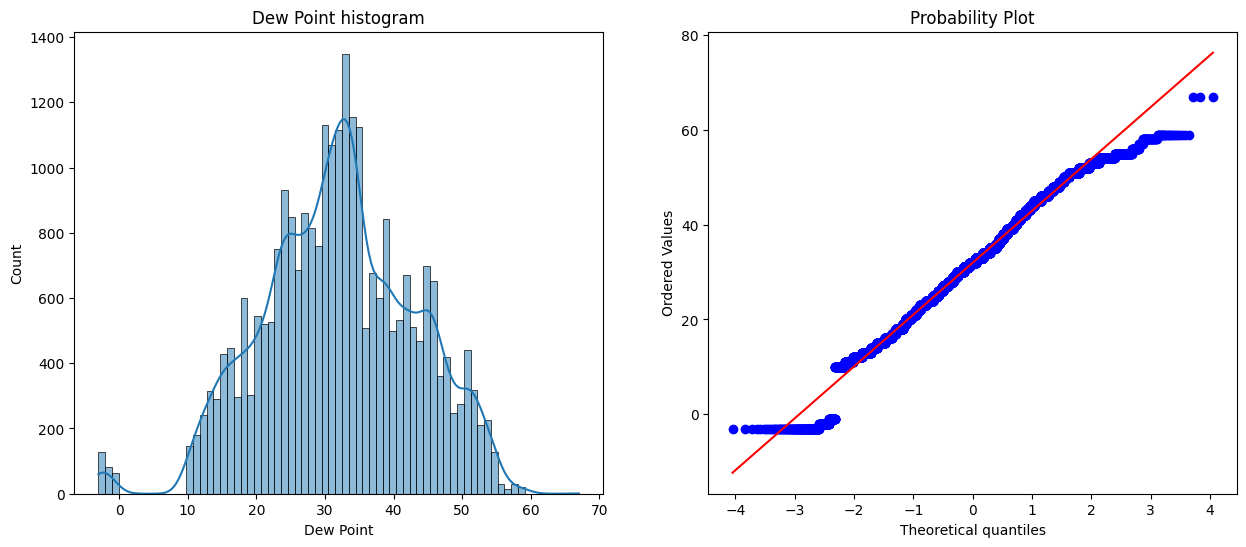

In [ ]:
plt.figure(figsize=(15,6))

plt.subplot(1,2,1)
plt.title('Dew Point histogram')
sns.histplot(data['Dew Point'].dropna(), kde=True)
plt.subplot(1,2,2)

stats.probplot(data['Dew Point'].dropna(), dist='norm', plot=plt)

In [ ]:
data[data['Dew Point'].isna()]

,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,OP_UNIQUE_CARRIER,DEST,DEP_DELAY,CRS_ELAPSED_TIME,DISTANCE,CRS_DEP_M,CRS_ARR_M,...,Humidity,Wind Speed,Wind Gust,Pressure,Condition,sch_dep,sch_arr,is_delayed,wind_sin,wind_cos
3547,11,11,1,9E,PWM,141,83,273,1340,1423,...,45,22,33,30.17,Fair / Windy,11,11,1,-7.071068e-01,0.707107
3849,11,12,2,B6,PSE,-8,239,1617,1260,119,...,43,16,28,30.12,Partly Cloudy,28,41,0,-3.420201e-01,0.939693
3850,11,12,2,OO,ORD,57,180,740,1195,1315,...,43,16,28,30.12,Partly Cloudy,28,41,1,-3.420201e-01,0.939693
3851,11,12,2,9E,RDU,6,124,427,1255,1379,...,43,16,28,30.12,Partly Cloudy,28,33,0,-3.420201e-01,0.939693
3852,11,12,2,DL,MSP,95,196,1029,1169,1305,...,43,16,28,30.12,Partly Cloudy,28,33,1,-3.420201e-01,0.939693
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25488,1,21,2,B6,BTV,-5,75,266,1375,10,...,43,10,0,30.46,Mostly Cloudy,16,31,0,-7.071068e-01,0.707107
25489,1,21,2,AA,LAX,89,390,2475,1290,60,...,43,8,0,30.46,Mostly Cloudy,16,31,1,-2.449294e-16,1.000000
25490,1,21,2,AA,BOS,-5,75,187,1390,25,...,43,8,0,30.46,Mostly Cloudy,15,20,0,-2.449294e-16,1.000000
25491,1,21,2,B6,SJU,-12,224,1598,1417,261,...,43,8,0,30.46,Mostly Cloudy,15,20,0,-2.449294e-16,1.000000


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28818 entries, 0 to 28817
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   MONTH              28818 non-null  int64  
 1   DAY_OF_MONTH       28818 non-null  int64  
 2   DAY_OF_WEEK        28818 non-null  int64  
 3   OP_UNIQUE_CARRIER  28818 non-null  object 
 4   DEST               28818 non-null  object 
 5   DEP_DELAY          28818 non-null  int64  
 6   CRS_ELAPSED_TIME   28818 non-null  int64  
 7   DISTANCE           28818 non-null  int64  
 8   CRS_DEP_M          28818 non-null  int64  
 9   CRS_ARR_M          28818 non-null  int64  
 10  Temperature        28818 non-null  int64  
 11  Dew Point          27093 non-null  float64
 12  Humidity           28818 non-null  int64  
 13  Wind Speed         28818 non-null  int64  
 14  Wind Gust          28818 non-null  int64  
 15  Pressure           28818 non-null  float64
 16  Condition          288

### Unique carriers column

In [ ]:
data['OP_UNIQUE_CARRIER'].unique()

array(['B6', 'DL', 'AA', 'AS', 'MQ', '9E', 'YX', 'HA', 'OO'], dtype=object)

In [ ]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False, drop='first')

OP_carriers = ohe.fit_transform(data[['OP_UNIQUE_CARRIER']])
OP_carriers

array([[0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       ...,
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.]], shape=(28818, 8))

In [ ]:
feature_names = ohe.get_feature_names_out(['OP_UNIQUE_CARRIER'])
feature_names

array(['OP_UNIQUE_CARRIER_AA', 'OP_UNIQUE_CARRIER_AS',
       'OP_UNIQUE_CARRIER_B6', 'OP_UNIQUE_CARRIER_DL',
       'OP_UNIQUE_CARRIER_HA', 'OP_UNIQUE_CARRIER_MQ',
       'OP_UNIQUE_CARRIER_OO', 'OP_UNIQUE_CARRIER_YX'], dtype=object)

In [ ]:
carriers_encoded = pd.DataFrame(OP_carriers, columns=feature_names)
carriers_encoded

,OP_UNIQUE_CARRIER_AA,OP_UNIQUE_CARRIER_AS,OP_UNIQUE_CARRIER_B6,OP_UNIQUE_CARRIER_DL,OP_UNIQUE_CARRIER_HA,OP_UNIQUE_CARRIER_MQ,OP_UNIQUE_CARRIER_OO,OP_UNIQUE_CARRIER_YX
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...
28813,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
28814,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
28815,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
28816,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
print("Shape of data:", data.shape)
print("Shape of carriers_encoded:", carriers_encoded.shape)

Shape of data: (28818, 22)
Shape of carriers_encoded: (28818, 8)


In [ ]:
carriers_encoded = carriers_encoded.reset_index()

In [ ]:
data = pd.concat([data, carriers_encoded], axis=1)
data

,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,OP_UNIQUE_CARRIER,DEST,DEP_DELAY,CRS_ELAPSED_TIME,DISTANCE,CRS_DEP_M,CRS_ARR_M,...,wind_cos,index,OP_UNIQUE_CARRIER_AA,OP_UNIQUE_CARRIER_AS,OP_UNIQUE_CARRIER_B6,OP_UNIQUE_CARRIER_DL,OP_UNIQUE_CARRIER_HA,OP_UNIQUE_CARRIER_MQ,OP_UNIQUE_CARRIER_OO,OP_UNIQUE_CARRIER_YX
0,11,1,5,B6,CHS,-1,124,636,324,448,...,-1.836970e-16,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,11,1,5,B6,LAX,-7,371,2475,340,531,...,-1.836970e-16,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,11,1,5,B6,FLL,40,181,1069,301,482,...,-1.836970e-16,2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,11,1,5,B6,MCO,-2,168,944,345,513,...,-1.836970e-16,3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,11,1,5,DL,ATL,-4,139,760,360,499,...,-1.836970e-16,4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28813,1,31,5,B6,ORH,2,57,150,1370,1427,...,1.000000e+00,28813,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
28814,1,31,5,AA,BOS,2,75,187,1390,25,...,1.000000e+00,28814,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
28815,1,31,5,AS,SEA,283,392,2422,1125,1337,...,1.000000e+00,28815,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
28816,1,31,5,B6,SJU,5,224,1598,1417,261,...,1.000000e+00,28816,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
data.drop(columns=['OP_UNIQUE_CARRIER'], inplace=True, axis=1)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28818 entries, 0 to 28817
Data columns (total 30 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   MONTH                 28818 non-null  int64  
 1   DAY_OF_MONTH          28818 non-null  int64  
 2   DAY_OF_WEEK           28818 non-null  int64  
 3   DEST                  28818 non-null  object 
 4   DEP_DELAY             28818 non-null  int64  
 5   CRS_ELAPSED_TIME      28818 non-null  int64  
 6   DISTANCE              28818 non-null  int64  
 7   CRS_DEP_M             28818 non-null  int64  
 8   CRS_ARR_M             28818 non-null  int64  
 9   Temperature           28818 non-null  int64  
 10  Dew Point             27093 non-null  float64
 11  Humidity              28818 non-null  int64  
 12  Wind Speed            28818 non-null  int64  
 13  Wind Gust             28818 non-null  int64  
 14  Pressure              28818 non-null  float64
 15  Condition          

### Destination column

### Train-Test Split (Before Target Encoding)

In [ ]:
from sklearn.model_selection import train_test_split

# Prepare features and target
X = data.drop(['is_delayed'], axis=1)
y = data['is_delayed']

# Stratified train-test split to maintain class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Train target distribution: {y_train.value_counts(normalize=True)}")
print(f"Test target distribution: {y_test.value_counts(normalize=True)}")

Train set shape: (23054, 29)
Test set shape: (5764, 29)
Train target distribution: is_delayed
0    0.860501
1    0.139499
Name: proportion, dtype: float64
Test target distribution: is_delayed
0    0.860514
1    0.139486
Name: proportion, dtype: float64


### Target Encoding for DEST (No Data Leakage)

In [ ]:
# Calculate target encoding ONLY on training set
train_data = X_train.copy()
train_data['is_delayed'] = y_train

# Calculate mean delay rate for each destination using only training data
dest_target_encoding = train_data.groupby('DEST')['is_delayed'].mean().to_dict()

# Apply encoding to both train and test sets
X_train['DEST_target_encoded'] = X_train['DEST'].map(dest_target_encoding)
X_test['DEST_target_encoded'] = X_test['DEST'].map(dest_target_encoding)

# Handle unseen destinations in test set (if any) with overall mean
overall_mean = y_train.mean()
X_test['DEST_target_encoded'].fillna(overall_mean, inplace=True)

# Drop original DEST column
X_train.drop(['DEST'], axis=1, inplace=True)
X_test.drop(['DEST'], axis=1, inplace=True)

print(f"Target encoding completed.")
print(f"Train set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Missing values in train DEST_target_encoded: {X_train['DEST_target_encoded'].isnull().sum()}")
print(f"Missing values in test DEST_target_encoded: {X_test['DEST_target_encoded'].isnull().sum()}")

Target encoding completed.
Train set shape: (23054, 29)
Test set shape: (5764, 29)
Missing values in train DEST_target_encoded: 0
Missing values in test DEST_target_encoded: 0


/tmp/ipykernel_35661/613720230.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_test['DEST_target_encoded'].fillna(overall_mean, inplace=True)


### Logistic Regression Model